# Classification after clustering

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.model_selection import cross_val_score
from sklearn.metrics import ConfusionMatrixDisplay




warnings.filterwarnings("ignore")
pd.pandas.set_option("display.max_columns", None)
# Create Dataframe
df = pd.read_csv(r"./data/clustered_data_my.csv")
# Print shape of dataset
print(df.shape)

(2240, 22)


In [26]:
df.head()

,Age,Education,Marital_Status,Parental_Status,Children,Income,Total_Spending,Days_as_Customer,Recency,Wines,Fruits,Meat,Fish,Sweets,Gold,Web,Catalog,Store,Discount Purchases,Total_Promo,NumWebVisitsMonth,cluster
0,68,2,0,0,0,58138.0,1617.0,5087,58,635,81,546,120.5,81,88.0,8,10,4,3,0,7,0
1,71,2,0,1,2,46344.0,27.0,4241,38,11,1,6,2.0,1,6.0,1,1,2,2,0,5,1
2,60,2,1,0,0,71613.0,776.0,4588,26,426,49,127,111.0,21,42.0,8,2,10,1,0,4,0
3,41,2,1,1,1,26646.0,53.0,4181,26,11,4,20,10.0,3,5.0,2,0,4,2,0,6,1
4,44,4,1,1,1,58293.0,422.0,4437,94,173,43,118,46.0,27,15.0,5,3,6,5,0,5,2


In [27]:
df.columns

Index(['Age', 'Education', 'Marital_Status', 'Parental_Status', 'Children',
       'Income', 'Total_Spending', 'Days_as_Customer', 'Recency', 'Wines',
       'Fruits', 'Meat', 'Fish', 'Sweets', 'Gold', 'Web', 'Catalog', 'Store',
       'Discount Purchases', 'Total_Promo', 'NumWebVisitsMonth', 'cluster'],
      dtype='object')

**Now Spliting X and y**
- Why nned to split our data?
> Training Dataset is the part of Original Dataset that we use to train our ML model. The model learns on this data by running the algorithm and maps a function F(x) where “x” in the independent variable (inputs) for “y” where “y” is the dependent variable(output).

In [28]:
X = df.drop("cluster", axis=1) #dropping the target column which is 'cluster'
y = df["cluster"]

## Grid Search

- Why do we use Grid Search?

`GridSearchCV` is a technique to search through the best parameter values from the given set of the grid of parameters. It is basically a cross-validation method. the model and the parameters are required to be fed in. Best parameter values are extracted and then the predictions are made.    

We will use this later at last for hyperparameter tuning

## Selecting the best model
- so here we have some list of the best classification algorithms we imported. Now we will compare each model's score and see which model is performing better than rest of the others

In [29]:
# !pip install catboost==1.2

In [30]:

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report,ConfusionMatrixDisplay, \
                            precision_score, recall_score, f1_score, roc_auc_score,roc_curve,confusion_matrix
from xgboost import XGBClassifier
#from catboost import CatBoostClassifier
from sklearn import metrics 

models = {
    "Random Forest": RandomForestClassifier(random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    "Logistic Regression": LogisticRegression(),
     "K-Neighbors Classifier": KNeighborsClassifier(),
    "XGBClassifier": XGBClassifier(random_state=42), 
     #"CatBoosting Classifier": CatBoostClassifier(verbose=False),
    "AdaBoost Classifier": AdaBoostClassifier(random_state=42)
}

-  This function will check each model's performance so that we can compare with each other

In [31]:
# Create a function which can evaluate models and return a report 
def evaluate_models(X, y, models):
    '''
    This function takes in X and y and models dictionary as input
    It splits the data into Train Test split
    Iterates through the given model dictionary and evaluates the metrics
    Returns: Dataframe which contains report of all models metrics with cost
    '''
    # separate dataset into train and test
    X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)
    

    models_list = []
    scores = []
    
    for i in range(len(list(models))):
        model = list(models.values())[i]
        model.fit(X_train, y_train) # Train model

        # Make predictions
        y_pred = model.predict(X_test)

        score = accuracy_score(y_test,y_pred)
        
        model_name = list(models.keys())[i]
        print(f'---- score for --- {model_name} ----')
        print(f"{score}")
        models_list.append(model_name)
        scores.append(score)
    
    print()
    
    report = pd.DataFrame()
    report['Model_name'] = models_list
    report['Score'] = scores        
    return report

checing the score of mode report

In [32]:
report = evaluate_models(X, y, models)

---- score for --- Random Forest ----
0.9598214285714286
---- score for --- Decision Tree ----
0.9441964285714286
---- score for --- Gradient Boosting ----
0.9620535714285714
---- score for --- Logistic Regression ----
0.8772321428571429
---- score for --- K-Neighbors Classifier ----
0.8125
---- score for --- XGBClassifier ----
0.9642857142857143
---- score for --- AdaBoost Classifier ----
0.9017857142857143



In [33]:
report.sort_values('Score')

,Model_name,Score
4,K-Neighbors Classifier,0.812500
3,Logistic Regression,0.877232
6,AdaBoost Classifier,0.901786
1,Decision Tree,0.944196
0,Random Forest,0.959821
2,Gradient Boosting,0.962054
5,XGBClassifier,0.964286


- ### From the report above we can see that the xgb classifier model performed the best, so we will continue training our model using XGB classifier algorithm.

### Splitting the dataset into training and testing sets

Before training the final model, we divide the dataset into two parts:

- **Training Set** – used to train the machine learning model.
- **Testing Set** – used to evaluate how well the model performs on unseen data.

This helps us measure the generalization ability of the model.

In [35]:
# Separate data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    random_state=42,
    test_size=0.3
)

X_train.head()

,Age,Education,Marital_Status,Parental_Status,Children,Income,Total_Spending,Days_as_Customer,Recency,Wines,Fruits,Meat,Fish,Sweets,Gold,Web,Catalog,Store,Discount Purchases,Total_Promo,NumWebVisitsMonth
994,71,2,0,1,2,64587.0,108.0,4283,49,66,0,16,0.0,6,20.0,1,1,4,2,0,3
2162,68,2,1,1,1,47320.0,414.0,4813,10,200,19,111,50.0,15,19.0,5,1,8,6,0,6
906,64,2,0,0,0,86429.0,1449.0,4496,10,464,28,556,29.0,18,37.0,7,4,7,0,1,2
572,47,1,0,1,1,38593.0,177.0,4565,42,51,12,49,17.0,24,24.0,4,1,3,3,0,8
1877,67,2,1,0,0,72905.0,1515.0,4435,52,407,81,445,120.5,81,126.5,3,7,9,1,1,1


### Hyperparameter Tuning

Machine learning models have two types of parameters:

1. **Model Parameters**
   - Learned automatically from the data during training.

2. **Hyperparameters**
   - Set before training begins.
   - Control the behavior and complexity of the model.

To find the best combination of hyperparameters, we use **GridSearchCV**, which tests multiple combinations and selects the best performing configuration using cross-validation.

In [37]:
from sklearn.model_selection import GridSearchCV
from xgboost import XGBClassifier

# Parameter grid for tuning
params = {
    "n_estimators": [100, 200, 300],
    "max_depth": [3, 5, 7],
    "learning_rate": [0.01, 0.05, 0.1],
    "subsample": [0.8, 1],
    "colsample_bytree": [0.8, 1]
}

xgb = XGBClassifier(random_state=42, eval_metric='mlogloss')

xgb_cv = GridSearchCV(
    estimator=xgb,
    param_grid=params,
    cv=5,
    scoring="accuracy",
    n_jobs=1
)

xgb_cv.fit(X_train, y_train)

print("Best Hyperparameters:", xgb_cv.best_params_)
print("Best Cross Validation Score:", xgb_cv.best_score_)

Best Hyperparameters: {'colsample_bytree': 0.8, 'learning_rate': 0.05, 'max_depth': 5, 'n_estimators': 300, 'subsample': 0.8}
Best Cross Validation Score: 0.9700270649762928


### Training the Final XGBoost Model

After performing hyperparameter tuning, we now train the XGBoost model using the **best parameters found by GridSearchCV**.

In [38]:
best_xgb_model = XGBClassifier(
    **xgb_cv.best_params_,
    random_state=42,
    eval_metric='mlogloss'
)

best_model = best_xgb_model.fit(X_train, y_train)

### Model Evaluation

To evaluate the model performance, we use:

- **Accuracy Score** – measures overall prediction accuracy.
- **Classification Report** – shows precision, recall, and F1-score for each class.

In [39]:
from sklearn.metrics import accuracy_score, classification_report

y_pred = best_model.predict(X_test)

score = accuracy_score(y_test, y_pred)
cr = classification_report(y_test, y_pred)

print("XGBoost Classifier")
print("Accuracy Score value: {:.4f}".format(score))
print(cr)

XGBoost Classifier
Accuracy Score value: 0.9628
              precision    recall  f1-score   support

           0       0.96      0.96      0.96       179
           1       1.00      0.96      0.98       258
           2       0.93      0.97      0.95       235

    accuracy                           0.96       672
   macro avg       0.96      0.96      0.96       672
weighted avg       0.96      0.96      0.96       672



### Confusion Matrix

A confusion matrix helps us visualize how well the classification model performs by comparing the **actual labels** with the **predicted labels**.

It shows:

- Correct predictions
- Misclassifications
- Distribution of predictions across classes

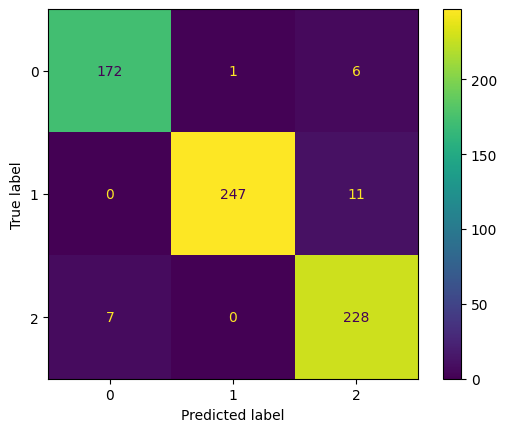

In [40]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(best_model, X_test, y_test)

## Model Summary

From the evaluation results, we observe that the **XGBoost classifier achieved the highest performance among all tested models**.

Key observations:

- XGBoost captured complex relationships in the dataset effectively.
- The tuned hyperparameters further improved the model performance.
- The confusion matrix and classification report show strong predictive capability across different clusters.

Therefore, **XGBoost was selected as the final classification model for predicting customer segments.**

### Final Model Results

After comparing multiple classification algorithms, the XGBoost classifier achieved the best performance among all models.

Using GridSearchCV, optimal hyperparameters were identified and the final model was trained using these parameters.

The tuned XGBoost model achieved:

• Cross-Validation Accuracy: 97.0%  
• Test Accuracy: 96.28%

The classification report shows strong precision, recall, and F1-scores across all customer clusters, indicating consistent model performance.

The confusion matrix further confirms that the majority of predictions were correct, with only a small number of misclassifications.

Overall, the model demonstrates strong predictive capability and generalizes well to unseen data, making it suitable for predicting customer segments based on behavioral and demographic features.

In [42]:
import pickle

#defining the path where the model should be saved
model_path="model.pkl"

#Save the model as .pkl file
with open(model_path,"wb") as model_file:
  pickle.dump(best_model,model_file)
  
  print(f"Best model saved successfully at {model_path}")

Best model saved successfully at model.pkl


In [43]:
import pickle

model = pickle.load(open("model.pkl", "rb"))
print(type(model))

<class 'xgboost.sklearn.XGBClassifier'>
